In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt


<Axes: >

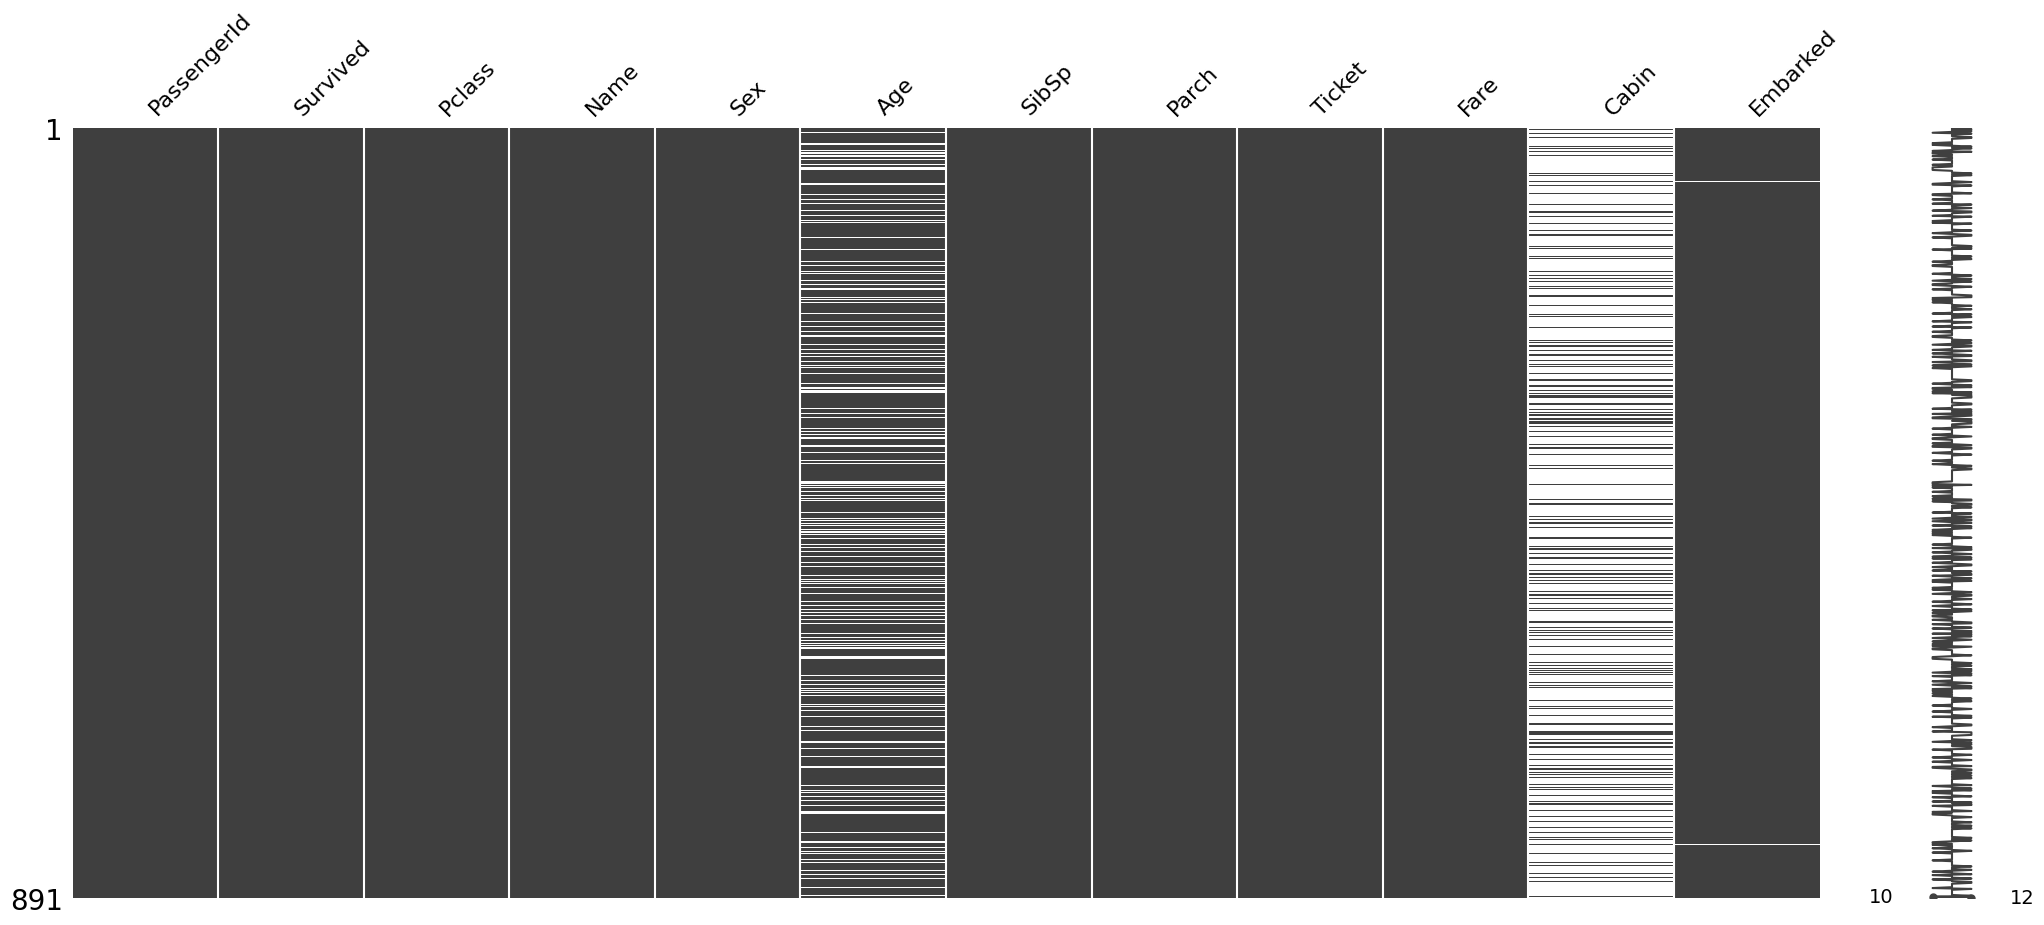

In [20]:
titanic_train = pd.read_csv('Titanic_train.csv')
msno.matrix(Titanic_train)

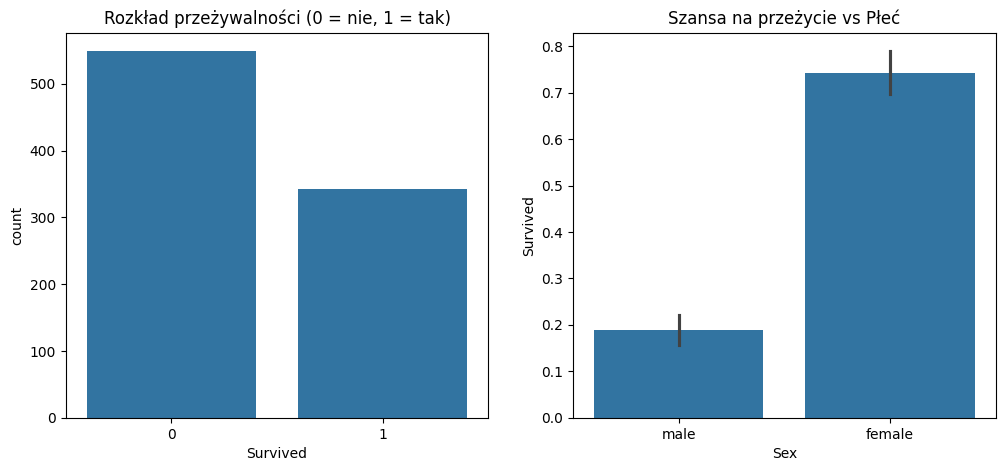

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# 1. Ile osób przeżyło? (target variable)
sns.countplot(x='Survived', data=titanic_train, ax=ax[0])
ax[0].set_title('Rozkład przeżywalności (0 = nie, 1 = tak)')
# 2. Przeżywalność w zależności od płci (bardzo ważna cecha na Titanicu)
sns.barplot(x='Sex', y='Survived', data=titanic_train, ax=ax[1])
ax[1].set_title('Szansa na przeżycie vs Płeć')
plt.show()

In [26]:
titanic_train.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [28]:
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [30]:
min_row = titanic_train.loc[(titanic_train['Age'].idxmin())]
min_row

PassengerId                                804
Survived                                     1
Pclass                                       3
Name           Thomas, Master. Assad Alexander
Sex                                       male
Age                                       0.42
SibSp                                        0
Parch                                        1
Ticket                                    2625
Fare                                    8.5167
Cabin                                      NaN
Embarked                                     C
Name: 803, dtype: object

In [33]:
titanic_train_prepared = titanic_train.copy()
titanic_train_prepared.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [34]:
titanic_train_prepared.drop(['PassengerId'], axis=1, inplace=True)
titanic_train_prepared

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [37]:
titanic_train_prepared['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [38]:
titanic_train_prepared['Pclass'].value_counts(normalize=True)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

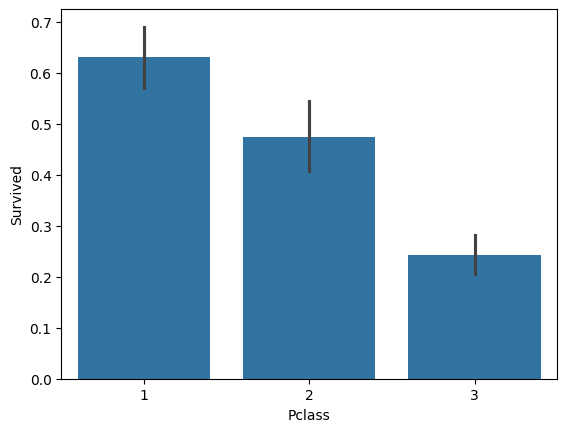

In [39]:
sns.barplot(x='Pclass', y='Survived', data=titanic_train_prepared)
plt.show()

In [40]:
titanic_train_prepared = pd.concat([titanic_train_prepared, pd.get_dummies(titanic_train_prepared['Pclass'], drop_first=True)],  axis=1)
titanic_train_prepared

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,2,3
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,True,False
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,False,False
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,False,True
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,False,False


In [41]:
titanic_train_prepared['Title'] = titanic_train_prepared['Name'].str.split(', ', expand=True)[1].str.split('.',  expand=True)[0]
titanic_train_prepared.drop(['Name'], axis=1, inplace=True)
titanic_train_prepared

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,2,3,Title
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,Mr
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,Mrs
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,Miss
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False,False,Mrs
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,False,True,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,NaN,S,True,False,Rev
887,1,1,female,19.0,0,0,112053,30.0000,B42,S,False,False,Miss
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,False,True,Miss
889,1,1,male,26.0,0,0,111369,30.0000,C148,C,False,False,Mr


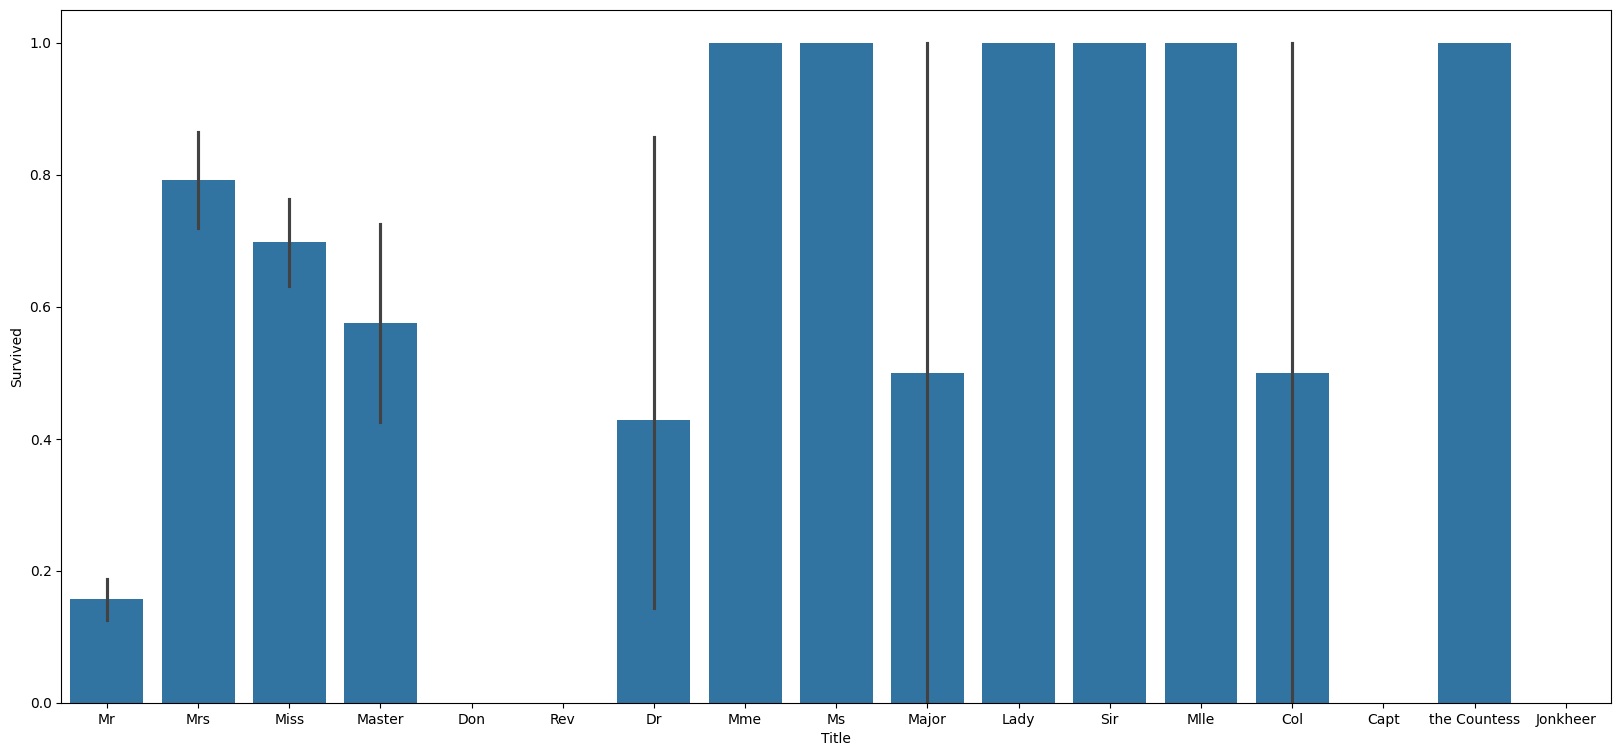

In [42]:
plt.figure(figsize=(20, 9))
sns.barplot(x='Title', y='Survived', data=titanic_train_prepared)
plt.show()

In [43]:
titanic_train_prepared['Title'].value_counts(normalize=True)


Title
Mr              0.580247
Miss            0.204265
Mrs             0.140292
Master          0.044893
Dr              0.007856
Rev             0.006734
Major           0.002245
Mlle            0.002245
Col             0.002245
Don             0.001122
Mme             0.001122
Ms              0.001122
Lady            0.001122
Sir             0.001122
Capt            0.001122
the Countess    0.001122
Jonkheer        0.001122
Name: proportion, dtype: float64

In [46]:
titanic_train_prepared.loc[~titanic_train_prepared['Title'].isin(['Mr', 'Miss', 'Mrs']), 'Title'] = 'Other'
titanic_train_prepared


,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,2,3,Title
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,Mr
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,Mrs
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,Miss
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False,False,Mrs
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,False,True,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,NaN,S,True,False,Other
887,1,1,female,19.0,0,0,112053,30.0000,B42,S,False,False,Miss
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,False,True,Miss
889,1,1,male,26.0,0,0,111369,30.0000,C148,C,False,False,Mr


In [47]:
titanic_train_prepared = pd.concat([titanic_train_prepared, pd.get_dummies(titanic_train_prepared['Title'], drop_first=True)], axis=1)
titanic_train_prepared.drop(['Title'], axis=1, inplace=True)
titanic_train_prepared

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,2,3,Mr,Mrs,Other
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,True,False,False
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,False,True,False
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,False,False,False
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False,False,False,True,False
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,NaN,S,True,False,False,False,True
887,1,1,female,19.0,0,0,112053,30.0000,B42,S,False,False,False,False,False
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,False,True,False,False,False
889,1,1,male,26.0,0,0,111369,30.0000,C148,C,False,False,True,False,False


In [48]:
titanic_train_prepared = pd.concat([titanic_train_prepared, pd.get_dummies(titanic_train_prepared['Sex'], drop_first=True)], axis=1)
titanic_train_prepared.drop(['Sex'], axis=1, inplace=True)
titanic_train_prepared

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,2,3,Mr,Mrs,Other,male
0,0,3,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,True,False,False,True
1,1,1,38.0,1,0,PC 17599,71.2833,C85,C,False,False,False,True,False,False
2,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,False,False,False,False
3,1,1,35.0,1,0,113803,53.1000,C123,S,False,False,False,True,False,False
4,0,3,35.0,0,0,373450,8.0500,NaN,S,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,211536,13.0000,NaN,S,True,False,False,False,True,True
887,1,1,19.0,0,0,112053,30.0000,B42,S,False,False,False,False,False,False
888,0,3,NaN,1,2,W./C. 6607,23.4500,NaN,S,False,True,False,False,False,False
889,1,1,26.0,0,0,111369,30.0000,C148,C,False,False,True,False,False,True


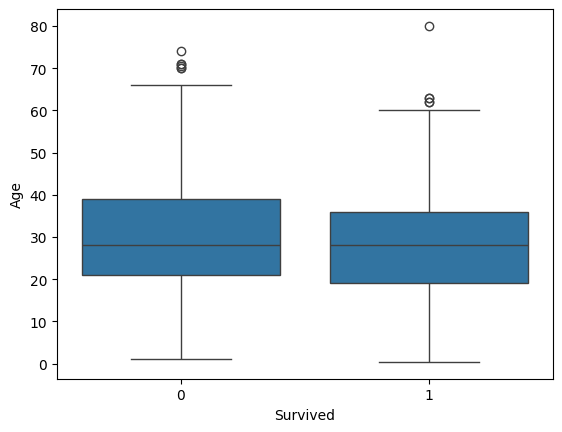

In [49]:
sns.boxplot(y='Age', x='Survived', data=titanic_train_prepared)
plt.show()

<Axes: >

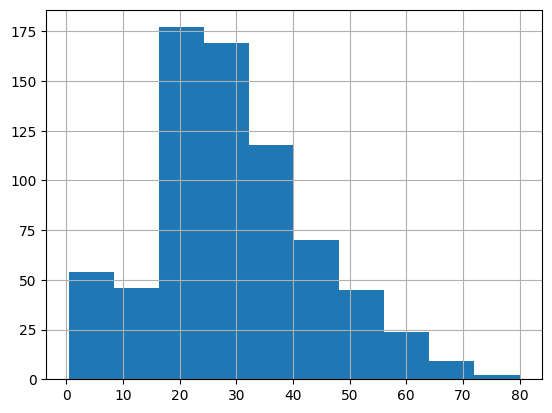

In [50]:
titanic_train_prepared['Age'].hist()

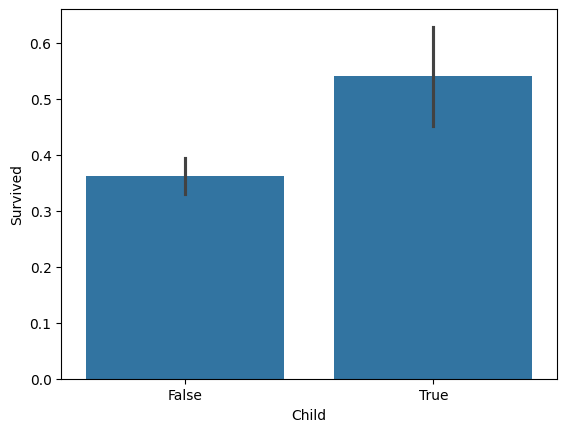

In [82]:
titanic_train_prepared['Child'] = titanic_train_prepared['Age'] < 18
sns.barplot(x='Child', y='Survived', data=titanic_train_prepared)
plt.show()

In [83]:
age_median = titanic_train_prepared['Age'].median()
titanic_train_prepared['Age'] = titanic_train_prepared['Age'].fillna(age_median)
titanic_train_prepared

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,2,3,Mr,Mrs,Other,male,Child
0,0,3,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True,True,False,False,True,False
1,1,1,38.0,1,0,PC 17599,71.2833,C85,C,False,False,False,True,False,False,False
2,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,True,False,False,False,False,False
3,1,1,35.0,1,0,113803,53.1000,C123,S,False,False,False,True,False,False,False
4,0,3,35.0,0,0,373450,8.0500,NaN,S,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,211536,13.0000,NaN,S,True,False,False,False,True,True,False
887,1,1,19.0,0,0,112053,30.0000,B42,S,False,False,False,False,False,False,False
888,0,3,28.0,1,2,W./C. 6607,23.4500,NaN,S,False,True,False,False,False,False,False
889,1,1,26.0,0,0,111369,30.0000,C148,C,False,False,True,False,False,True,False


<Axes: >

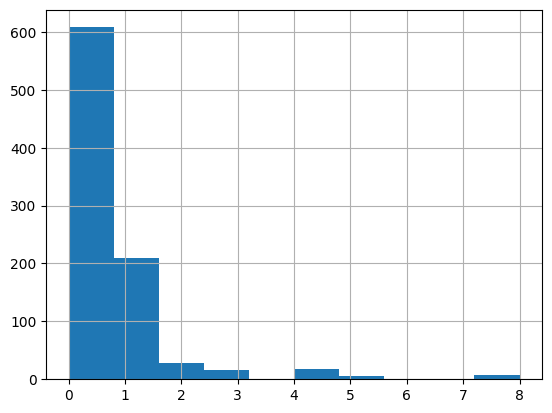

In [80]:
titanic_train_prepared['SibSp'].hist()

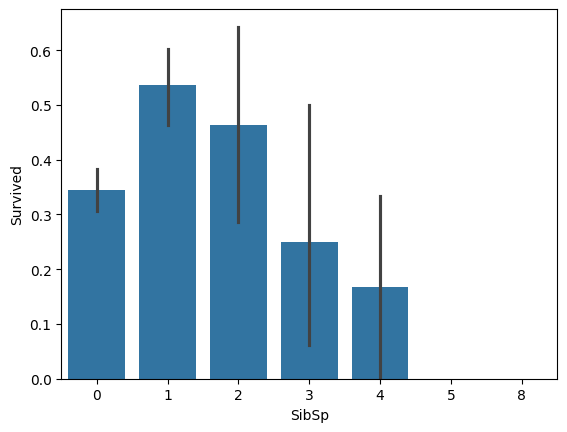

In [81]:

sns.barplot(x='SibSp', y='Survived', data=titanic_train_prepared)
plt.show()

In [87]:
titanic_train_prepared

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,2,3,Mr,Mrs,Other,male,Child
0,0,3,22.0,1,0,7.2500,S,False,True,True,False,False,True,False
1,1,1,38.0,1,0,71.2833,C,False,False,False,True,False,False,False
2,1,3,26.0,0,0,7.9250,S,False,True,False,False,False,False,False
3,1,1,35.0,1,0,53.1000,S,False,False,False,True,False,False,False
4,0,3,35.0,0,0,8.0500,S,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,True,False,False,False,True,True,False
887,1,1,19.0,0,0,30.0000,S,False,False,False,False,False,False,False
888,0,3,28.0,1,2,23.4500,S,False,True,False,False,False,False,False
889,1,1,26.0,0,0,30.0000,C,False,False,True,False,False,True,False


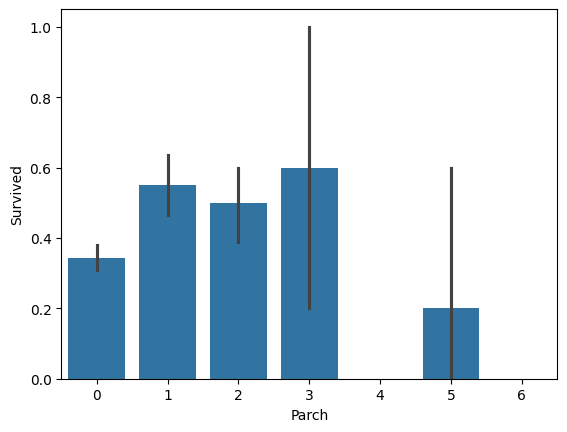

In [89]:

sns.barplot(x='Parch', y='Survived', data=titanic_train_prepared)
plt.show()

<Axes: >

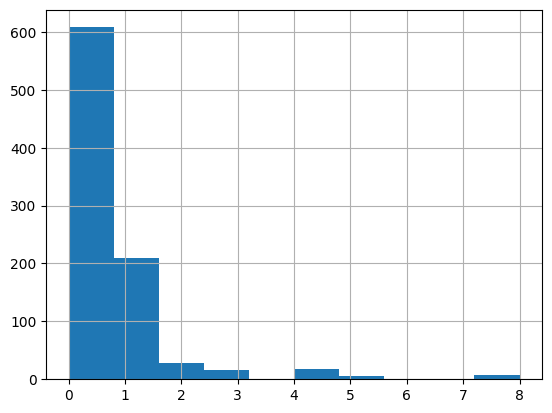

In [90]:
titanic_train_prepared['SibSp'].hist()